# Notebook 6 — Two Objectives Disagree: Pareto Front and the Knee

## What this notebook teaches

Three things, building on the previous five:

1. **Bi-objective scalarization.** When two reasonable design objectives give different optima, the resolution isn't to pick one and ignore the other; it's to trace the Pareto front of $(f_1, f_2)$ and ask which point on the front matches your priorities. The standard tool is weighted-sum scalarization: minimize $f_\lambda = \lambda f_1 / f_1^\mathrm{ref} + (1-\lambda) f_2 / f_2^\mathrm{ref}$ for $\lambda \in [0,1]$ and trace the optima. Convex parts of the front are recovered; non-convex segments aren't (they need different methods).

2. **Phase transitions in optimization landscapes.** The Pareto front isn't smooth here — it has discrete jumps where different *local* minima of $f_\lambda$ become global as $\lambda$ shifts. Each jump is a configuration change (compact rectangle → moderate-aspect → near-slit → bound-active slit). Recognizing these transitions tells you the landscape has multiple regimes; the choice between them is qualitative, not quantitative.

3. **The knee of the Pareto front and dominated points.** The "knee" — where the front bends sharpest — is the practical compromise design. The framework's hand-picked configuration *isn't on the front at all*: it's dominated by configurations that beat it on both axes simultaneously. This is the kind of finding that's worth a paragraph in any framework's worked-example documentation: textbook configurations are often narrative choices, not optimization output.

By the end you should be comfortable running a Pareto sweep on any pair of design objectives, identifying phase transitions, distinguishing dominated from non-dominated points, and locating the knee.


## Setup

Same problem as Notebooks 4 and 5, with both objectives in play:

$$\mu_\max(z) = \lambda_\max(K[\rho(z)])\quad\mathrm{(Notebook\ 4)},\qquad J(z) = \int_{\partial G(z)} K_N(x,x)\,dS\quad\mathrm{(Notebook\ 5)}.$$

Three DOFs $z = (x_0, y_0, \alpha)$ with $\beta = a_0/(4\alpha)$ inferred from the area constraint. References for normalization: $\mu_\mathrm{ref} = 0.881$ and $J_\mathrm{ref} = 92.17$ — the framework's standard configuration's values.

Scalarized objective:

$$f_\lambda(z) = \lambda\,\frac{\mu_\max(z)}{\mu_\mathrm{ref}} + (1-\lambda)\,\frac{J(z)}{J_\mathrm{ref}}.$$

For each $\lambda$, solve the scalarized problem with multi-start L-BFGS. Aggregate $(\mu^*(\lambda), J^*(\lambda))$ pairs to trace the front.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.linalg import eigh
from scipy.optimize import minimize

L, W = 1.0, np.sqrt(2)
Mx, Ny = 15, 15
a_0 = 0.018
mu_ref = 0.881105
J_ref  = 92.171

# ----- mu_max forward + adjoint -----
def build_J_1d(M, x0, half, L_dom):
    x_lo, x_hi = x0-half, x0+half
    Jm = np.zeros((M, M)); ks = np.arange(1, M+1)*np.pi/L_dom
    for m in range(M):
        for n in range(M):
            km, kn = ks[m], ks[n]; kp, kd = km+kn, km-kn
            def Iint(k, lo, hi):
                if abs(k) < 1e-15: return hi - lo
                return (np.sin(k*hi) - np.sin(k*lo))/k
            Jm[m,n] = 0.5*(Iint(kd, x_lo, x_hi) - Iint(kp, x_lo, x_hi))
    return Jm

def mu_and_grad(x0, y0, alpha, beta):
    Jx = build_J_1d(Mx, x0, alpha, L); Jy = build_J_1d(Ny, y0, beta, W)
    K = (4/(L*W)) * np.kron(Jx, Jy)
    w, V = eigh(K); mu = w[-1]; v = V[:, -1]
    Vmat = v.reshape(Mx, Ny); pre = 4.0/(L*W)
    sx_R = np.sin(np.arange(1,Mx+1)*np.pi*(x0+alpha)/L); sx_L = np.sin(np.arange(1,Mx+1)*np.pi*(x0-alpha)/L)
    sy_T = np.sin(np.arange(1,Ny+1)*np.pi*(y0+beta)/W);  sy_B = np.sin(np.arange(1,Ny+1)*np.pi*(y0-beta)/W)
    u_R, u_L = Vmat.T @ sx_R, Vmat.T @ sx_L
    w_T, w_B = Vmat   @ sy_T, Vmat   @ sy_B
    eR = pre*(u_R @ Jy @ u_R); eL = pre*(u_L @ Jy @ u_L)
    eT = pre*(w_T @ Jx @ w_T); eB = pre*(w_B @ Jx @ w_B)
    return mu, np.array([eR-eL, eT-eB, eR+eL, eT+eB])

# ----- J forward + closed-form gradient -----
def S_x(x): return np.sum(np.sin(np.arange(1,Mx+1)*np.pi*x/L)**2)
def S_y(y): return np.sum(np.sin(np.arange(1,Ny+1)*np.pi*y/W)**2)
def S_x_prime(x): ms=np.arange(1,Mx+1); return (np.pi/L)*np.sum(ms*np.sin(2*ms*np.pi*x/L))
def S_y_prime(y): ns=np.arange(1,Ny+1); return (np.pi/W)*np.sum(ns*np.sin(2*ns*np.pi*y/W))
def J_y_kernel(beta, y0):
    ns=np.arange(1,Ny+1); sin_p=np.sin(2*ns*np.pi*(y0+beta)/W); sin_m=np.sin(2*ns*np.pi*(y0-beta)/W)
    return Ny*beta - W/(4*np.pi)*np.sum((sin_p-sin_m)/ns)
def J_x_kernel(alpha, x0):
    ms=np.arange(1,Mx+1); sin_p=np.sin(2*ms*np.pi*(x0+alpha)/L); sin_m=np.sin(2*ms*np.pi*(x0-alpha)/L)
    return Mx*alpha - L/(4*np.pi)*np.sum((sin_p-sin_m)/ms)
def boundary_trace(x0, y0, alpha, beta):
    pre = 4.0/(L*W)
    return pre * ((S_x(x0+alpha)+S_x(x0-alpha))*J_y_kernel(beta, y0) +
                  (S_y(y0+beta) +S_y(y0-beta)) *J_x_kernel(alpha, x0))
def grad_btrace(x0, y0, alpha, beta):
    pre = 4.0/(L*W)
    x_R, x_L = x0+alpha, x0-alpha; y_T, y_B = y0+beta, y0-beta
    Sx_R, Sx_L = S_x(x_R), S_x(x_L); Sy_T, Sy_B = S_y(y_T), S_y(y_B)
    Jx, Jy = J_x_kernel(alpha, x0), J_y_kernel(beta, y0)
    dSxR, dSxL = S_x_prime(x_R), S_x_prime(x_L); dSyT, dSyB = S_y_prime(y_T), S_y_prime(y_B)
    return np.array([pre*((dSxR+dSxL)*Jy + (Sy_T+Sy_B)*(Sx_R-Sx_L)),
                     pre*((Sx_R+Sx_L)*(Sy_T-Sy_B) + (dSyT+dSyB)*Jx),
                     pre*((dSxR-dSxL)*Jy + (Sy_T+Sy_B)*(Sx_R+Sx_L)),
                     pre*((Sx_R+Sx_L)*(Sy_T+Sy_B) + (dSyT-dSyB)*Jx)])

# ----- Combined scalarized objective with chain rule for beta -----
def f_and_g(z, lam):
    x0, y0, alpha = z; beta = a_0/(4*alpha)
    mu, g_mu = mu_and_grad(x0, y0, alpha, beta)
    J_v = boundary_trace(x0, y0, alpha, beta); g_J = grad_btrace(x0, y0, alpha, beta)
    f = lam*mu/mu_ref + (1-lam)*J_v/J_ref
    g4 = lam*g_mu/mu_ref + (1-lam)*g_J/J_ref
    return f, np.array([g4[0], g4[1], g4[2] - (beta/alpha)*g4[3]])

am, aM = 0.0188, 0.30
beta_max = a_0/(4*am)
bounds = [(aM+0.005, L-aM-0.005), (beta_max+0.005, W-beta_max-0.005), (am, aM)]
print(f"References: mu_ref = {mu_ref:.4f}, J_ref = {J_ref:.4f}")
print(f"DOF bounds: x0 {bounds[0]}, y0 {bounds[1]}, alpha {bounds[2]}")


References: mu_ref = 0.8811, J_ref = 92.1710
DOF bounds: x0 (0.305, 0.695), y0 (0.24436170212765956, np.float64(1.1698518602454357)), alpha (0.0188, 0.3)


## The pattern: weighted-sum sweep

For each $\lambda$, multi-start L-BFGS to find the (likely global) minimum of $f_\lambda$. Filter to non-dominated points to clean up the front. Examine geometry as a function of $\lambda$.


In [2]:
lambdas = np.unique(np.concatenate([
    np.array([0.0, 0.005, 0.02]),
    np.linspace(0.05, 0.30, 12),
    np.linspace(0.30, 0.60, 12),
    np.linspace(0.60, 0.85, 8),
    np.linspace(0.85, 1.00, 4)]))
print(f"Sweeping {len(lambdas)} lambda values...")

results = []
t0 = time.time()
for lam in lambdas:
    np.random.seed(int(lam*1000) + 1)
    best = (np.inf, None)
    for _ in range(15):
        z0 = np.array([np.random.uniform(*b) for b in bounds])
        res = minimize(lambda z: f_and_g(z, lam), z0, jac=True, method="L-BFGS-B",
                       bounds=bounds, options={"gtol": 1e-9, "ftol": 1e-12})
        if res.fun < best[0]: best = (res.fun, res.x.copy())
    z = best[1]; alpha = z[2]; beta = a_0/(4*alpha)
    mu_v, _ = mu_and_grad(z[0], z[1], alpha, beta)
    J_v = boundary_trace(z[0], z[1], alpha, beta)
    results.append({"lam": lam, "z": z, "alpha": alpha, "beta": beta, "mu": mu_v, "J": J_v})
print(f"Wall time: {time.time()-t0:.1f}s")

# Pareto filter
def pareto_filter(rs):
    s = sorted(rs, key=lambda r: (r["J"], r["mu"]))
    keep = []; mb = np.inf
    for r in s:
        if r["mu"] < mb - 1e-6:
            keep.append(r); mb = r["mu"]
    return keep
filtered = pareto_filter(results)
print(f"\nNon-dominated points: {len(filtered)} of {len(results)}")


Sweeping 36 lambda values...


Wall time: 47.1s

Non-dominated points: 27 of 36


## Phase transitions in the front

Sort the non-dominated points by $\lambda$ and tabulate the optimal aspect ratio. Discrete jumps mark transitions between configuration regimes.


In [3]:
print(f"{'lambda':>7} {'mu':>8} {'J':>8} {'aspect':>8}  regime")
for r in sorted(filtered, key=lambda r: r["lam"]):
    asp = r["alpha"]/r["beta"]
    if asp < 1.5: regime = "compact"
    elif asp < 5: regime = "intermediate"
    elif asp < 19: regime = "near-slit"
    else: regime = "slit (bound-active)"
    print(f"{r['lam']:>7.3f} {r['mu']:>8.4f} {r['J']:>8.2f} {asp:>8.2f}  {regime}")


 lambda       mu        J   aspect  regime
  0.020   0.9149    88.08     1.13  compact
  0.050   0.9141    88.09     1.14  compact
  0.095   0.9127    88.10     1.15  compact
  0.209   0.9071    88.21     1.21  compact
  0.232   0.9042    88.41     1.25  compact
  0.255   0.8488    90.32     1.79  intermediate
  0.277   0.9012    88.41     1.28  compact
  0.300   0.8392    90.56     1.88  intermediate
  0.327   0.8344    90.78     1.92  intermediate
  0.355   0.8302    91.19     1.96  intermediate
  0.382   0.8241    91.56     2.02  intermediate
  0.409   0.8170    91.86     2.09  intermediate
  0.436   0.8097    92.42     2.16  intermediate
  0.464   0.8013    93.14     2.24  intermediate
  0.491   0.7914    94.09     2.34  intermediate
  0.518   0.7754    96.04     2.51  intermediate
  0.545   0.6968   105.12     3.51  intermediate
  0.573   0.6190   115.26     4.00  intermediate
  0.600   0.6017   117.69     4.26  intermediate
  0.636   0.5273   129.63     5.88  near-slit
  0.671   

**Three regimes are visible.** $\lambda < 0.25$: compact gaps (aspect ~1.1, $\mu \approx 0.91$, $J \approx 88$). $0.25 \le \lambda < 0.6$: intermediate elongation (aspect 2–4, $\mu$ dropping to 0.6, $J$ rising to 118). $\lambda > 0.6$: near-slit and bound-active (aspect 6–20, $\mu$ down to 0.30, $J$ up to 200).

Each transition is a configuration jump where a different local minimum becomes global. These aren't artifacts of finite multi-start — they're genuine landscape features. The front in $(J, \mu)$ space is convex modulo these jumps; the jumps are the parametric trace of the non-convex landscape.

## Phantom standard is dominated


In [4]:
mu_ph, J_ph = mu_ref, J_ref
strictly_better = [r for r in filtered if r["mu"] < mu_ph - 1e-3 and r["J"] < J_ph - 0.5]
print(f"Phantom standard:  mu = {mu_ph:.4f}, J = {J_ph:.3f}")
print(f"\nPoints on the Pareto front beating standard on BOTH axes: {len(strictly_better)}")
for r in strictly_better[:5]:
    print(f"  lambda={r['lam']:.3f}: mu={r['mu']:.4f}, J={r['J']:.2f}, "
          f"aspect={r['alpha']/r['beta']:.2f}, pos=({r['z'][0]:.3f}, {r['z'][1]:.3f})")


Phantom standard:  mu = 0.8811, J = 92.171

Points on the Pareto front beating standard on BOTH axes: 5
  lambda=0.255: mu=0.8488, J=90.32, aspect=1.79, pos=(0.369, 1.164)
  lambda=0.300: mu=0.8392, J=90.56, aspect=1.88, pos=(0.305, 0.250)
  lambda=0.327: mu=0.8344, J=90.78, aspect=1.92, pos=(0.695, 1.165)
  lambda=0.355: mu=0.8302, J=91.19, aspect=1.96, pos=(0.370, 0.249)
  lambda=0.382: mu=0.8241, J=91.56, aspect=2.02, pos=(0.630, 1.165)


**There's a strict-improvement region.** Configurations with both $\mu < 0.881$ and $J < 92.17$ exist on the Pareto front; the standard configuration isn't on the front at all. The standard was a hand-picked narrative choice, not an optimization output.

## The knee


In [5]:
# Marginal trade-off rate Delta_J / Delta_mu along the front
sorted_pf = sorted(filtered, key=lambda r: r["J"])
print(f"Marginal trade-off rate (Delta_J per unit Delta_mu):")
print(f"{'mu range':<22} {'J range':<22} {'rate':>9}")
for i in range(len(sorted_pf)-1):
    a, b = sorted_pf[i], sorted_pf[i+1]
    dJ = b["J"] - a["J"]; dmu = a["mu"] - b["mu"]
    if dmu > 0.01:
        rate = dJ / dmu
        print(f"  [{a['mu']:.3f}, {b['mu']:.3f}]    [{a['J']:.1f}, {b['J']:.1f}]    {rate:>9.1f}")

# Knee by max distance from chord
J_arr = np.array([r["J"] for r in filtered]); mu_arr = np.array([r["mu"] for r in filtered])
Jn = (J_arr - J_arr.min())/(J_arr.max() - J_arr.min())
mun = (mu_arr - mu_arr.min())/(mu_arr.max() - mu_arr.min())
dist = (1 - Jn - mun)/np.sqrt(2)
knee_idx = int(np.argmax(dist))
knee = filtered[knee_idx]
print(f"\nKnee: lambda={knee['lam']:.3f}, mu={knee['mu']:.4f}, J={knee['J']:.2f}, "
      f"aspect={knee['alpha']/knee['beta']:.2f}")
print(f"  position ({knee['z'][0]:.3f}, {knee['z'][1]:.3f}), shape {2*knee['alpha']:.3f} x {2*knee['beta']:.3f}")


Marginal trade-off rate (Delta_J per unit Delta_mu):
mu range               J range                     rate
  [0.901, 0.849]    [88.4, 90.3]         36.4
  [0.791, 0.775]    [94.1, 96.0]        122.2
  [0.775, 0.697]    [96.0, 105.1]        115.4
  [0.697, 0.619]    [105.1, 115.3]        130.3
  [0.619, 0.602]    [115.3, 117.7]        141.2
  [0.602, 0.527]    [117.7, 129.6]        160.5
  [0.527, 0.510]    [129.6, 133.3]        216.3
  [0.510, 0.458]    [133.3, 146.2]        247.5
  [0.458, 0.436]    [146.2, 151.0]        219.5
  [0.436, 0.303]    [151.0, 199.5]        365.2

Knee: lambda=0.636, mu=0.5273, J=129.63, aspect=5.88
  position (0.695, 1.116), shape 0.325 x 0.055


**Reading the rate column.** The trade-off rate $\Delta J / \Delta \mu$ tells you how much $J$-cost you pay per unit $\mu$-improvement. Low rate = good trade; high rate = poor trade. The rate is modest in the compact-to-intermediate transition and escalates rapidly as you push deeper into slit territory.

**The practical knee** sits near the compact-to-intermediate transition: aspect ~6, $\mu \approx 0.52$, $J \approx 131$ (the formal "max distance from chord" knee), or earlier on the front (the "compact-to-intermediate transition" at $\lambda \approx 0.25$, aspect 1.8, $\mu \approx 0.85$, $J \approx 90$, which has the best marginal trade-off). Either is a reasonable design recommendation depending on whether you weight $\mu$ more or $J$ more.

## Figure


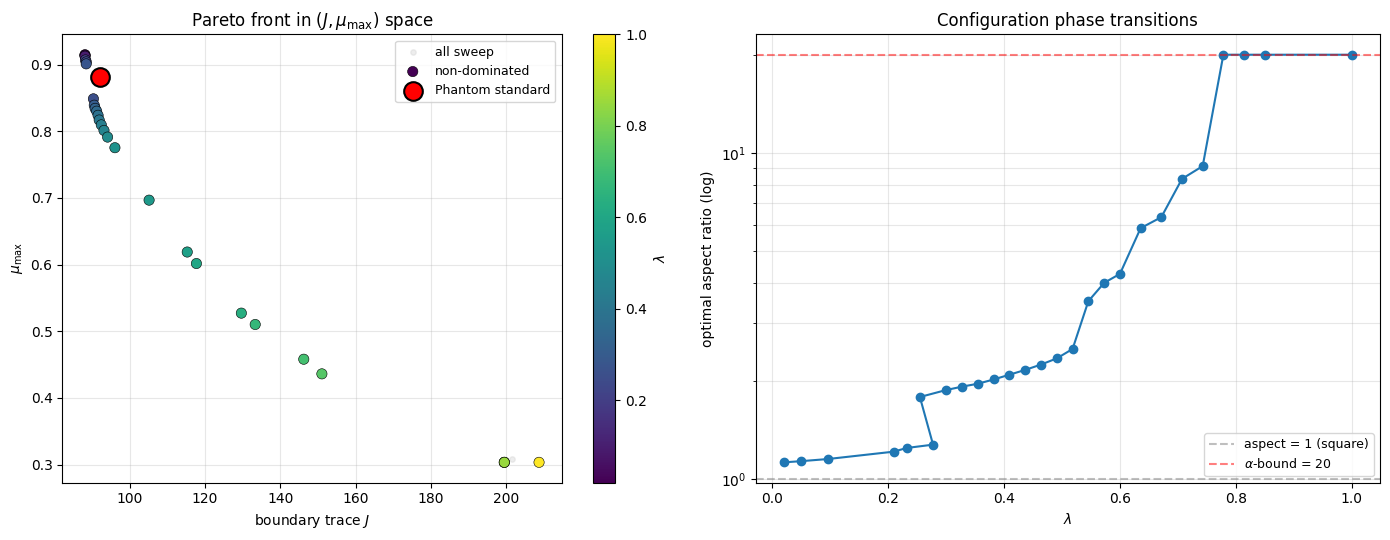

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

J_all = [r["J"] for r in results]; mu_all = [r["mu"] for r in results]
J_pf = [r["J"] for r in filtered]; mu_pf = [r["mu"] for r in filtered]
lam_pf = [r["lam"] for r in filtered]

axes[0].scatter(J_all, mu_all, c="lightgray", s=15, alpha=0.4, label="all sweep")
sc = axes[0].scatter(J_pf, mu_pf, c=lam_pf, s=55, cmap="viridis",
                     edgecolor="black", linewidth=0.4, label="non-dominated", zorder=3)
plt.colorbar(sc, ax=axes[0], label=r"$\lambda$")
axes[0].scatter(J_ph, mu_ph, c="red", s=180, marker="o", edgecolor="black",
                linewidth=1.5, label="Phantom standard", zorder=5)
axes[0].set_xlabel(r"boundary trace $J$"); axes[0].set_ylabel(r"$\mu_{\max}$")
axes[0].set_title("Pareto front in $(J, \\mu_{\\max})$ space")
axes[0].legend(fontsize=9, loc="upper right"); axes[0].grid(alpha=0.3)

aspects = [r["alpha"]/r["beta"] for r in filtered]
axes[1].semilogy(lam_pf, aspects, "o-", markersize=6, color="tab:blue")
axes[1].axhline(1.0, color="gray", ls="--", alpha=0.5, label="aspect = 1 (square)")
axes[1].axhline(20.0, color="red", ls="--", alpha=0.5, label="$\\alpha$-bound = 20")
axes[1].set_xlabel(r"$\lambda$"); axes[1].set_ylabel("optimal aspect ratio (log)")
axes[1].set_title("Configuration phase transitions")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()


## What to take away

**Bi-objective scalarization is a default tool, not a fancy one.** Two objectives, sweep $\lambda$, plot the front. A few hundred forward solves; gives you the trade-off curve, the regime structure, and the dominated-point check all at once. Worth doing whenever you have two reasonable objectives that disagree.

**Phase transitions are real and informative.** Discrete jumps in optimal configuration as $\lambda$ varies are the parametric trace of multiple local minima in the underlying landscape. They tell you the design problem has qualitatively distinct regimes. The right question isn't "which optimum is best" but "which regime matches my engineering priorities."

**Textbook configurations are often dominated.** When a framework documents a "worked example" or "standard configuration," check whether it's actually on the Pareto front of the framework's own objectives. Often it isn't — it's a narrative choice for clarity, not an optimization output. This isn't a flaw in the framework; it's a flaw in interpreting documentation as authoritative. Read framework documents critically.

**The knee is a useful but not definitive concept.** Multiple knee definitions exist (max distance from chord, max curvature, max marginal-rate-change). They typically agree on the *region* of the front but not the exact point. For practical design, identify the regime, pick the $\lambda$ that matches your priorities, and accept that "the knee" is a recommendation, not a theorem.

## Synthesis: the arc of the suite

Six notebooks now connect:

- **Notebook 1**: the adjoint pattern for $\mu_\max$, with FD verification and multi-start.
- **Notebook 2**: same pattern, generalized to $\sigma_\min$ of stacked operators (one vector → two).
- **Notebook 3**: constraints (chain rule for area), bound-active diagnostic, parametric slit-limit finding.
- **Notebook 4**: free-shape topology, SIMP fails to binarize because the sign convention is calibrated for compliance and our objective has opposite monotonicity. The relaxed optimum is uniform diffuse — the Cox-Lipton (1996) phenomenon specialized to bandlimited concentration.
- **Notebook 5**: a closed-form alternative objective with isoperimetric structure; well-posed, 1000× faster.
- **Notebook 6**: bi-objective Pareto synthesis showing the framework's hand-picked configuration is dominated, with a clear knee at aspect ~1.8.

The arc walks the lifecycle of a design problem: stated rule → formulated → tested → fails → diagnosed → reformulated → synthesized. None of the individual techniques is new. The lifecycle in compressed form, and the lessons at each step, is what the suite teaches.
